# Loading the Data

In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, classification_report, roc_auc_score

In [3]:
market = pd.read_csv('fear_greed_index.csv')
market.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trader = pd.read_csv('historical_data.csv')
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
market['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [6]:
trader['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [7]:
trader['Coin'].value_counts()

Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
        ...  
@18         1
@30         1
@25         1
@86         1
@68         1
Name: count, Length: 246, dtype: int64

In [8]:
trader['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [9]:
trader['Closed PnL'].describe()

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

In [10]:
trader['Crossed'].value_counts()

Crossed
True     128403
False     82821
Name: count, dtype: int64

# Data Cleaning

In [11]:
market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [12]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [13]:
market.duplicated().sum()

np.int64(0)

In [14]:
trader.duplicated().sum()

np.int64(0)

# Data Preprocessing

Time 

In [15]:
market['date'] = pd.to_datetime(market['timestamp'], unit='s')
trader['date'] = pd.to_datetime(trader['Timestamp'], unit='ms')
market['date_only'] = market['date'].dt.date
trader['date_only'] = trader['date'].dt.date
market.drop(['timestamp', 'date'], axis = 1, inplace = True)
trader.drop(['Timestamp IST', 'Timestamp', 'date'], axis = 1, inplace = True)
market.head()

,value,classification,date_only
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05


In [16]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date_only
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27


In [17]:
trader.drop(['Transaction Hash', 'Order ID', 'Trade ID'], axis = 1, inplace = True)

In [18]:
trader = trader.replace({
    'Crossed': {'False': 0, 'True': 1},
    'Side': {'SELL': 0, 'BUY': 1}}).infer_objects(copy=False)
trader.head()

C:\Users\Sanjana Akella\AppData\Local\Temp\ipykernel_29360\221348021.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trader = trader.replace({


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,date_only
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,1,0.000000,Buy,0.0,True,0.345404,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,1,986.524596,Buy,0.0,True,0.005600,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,1,1002.518996,Buy,0.0,True,0.050431,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,1,1146.558564,Buy,0.0,True,0.050043,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,1,1289.488521,Buy,0.0,True,0.003055,2024-10-27


# Integration

In [19]:
df = trader.merge(market[['date_only', 'classification', 'value']], on = 'date_only', how = 'left')
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,date_only,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,1,0.000000,Buy,0.0,True,0.345404,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,1,986.524596,Buy,0.0,True,0.005600,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,1,1002.518996,Buy,0.0,True,0.050431,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,1,1146.558564,Buy,0.0,True,0.050043,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,1,1289.488521,Buy,0.0,True,0.003055,2024-10-27,Greed,74.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Account          211224 non-null  object 
 1   Coin             211224 non-null  object 
 2   Execution Price  211224 non-null  float64
 3   Size Tokens      211224 non-null  float64
 4   Size USD         211224 non-null  float64
 5   Side             211224 non-null  int64  
 6   Start Position   211224 non-null  float64
 7   Direction        211224 non-null  object 
 8   Closed PnL       211224 non-null  float64
 9   Crossed          211224 non-null  bool   
 10  Fee              211224 non-null  float64
 11  date_only        211224 non-null  object 
 12  classification   184263 non-null  object 
 13  value            184263 non-null  float64
dtypes: bool(1), float64(7), int64(1), object(5)
memory usage: 21.2+ MB


In [21]:
df = df.dropna(subset=['classification', 'value'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184263 entries, 0 to 210767
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Account          184263 non-null  object 
 1   Coin             184263 non-null  object 
 2   Execution Price  184263 non-null  float64
 3   Size Tokens      184263 non-null  float64
 4   Size USD         184263 non-null  float64
 5   Side             184263 non-null  int64  
 6   Start Position   184263 non-null  float64
 7   Direction        184263 non-null  object 
 8   Closed PnL       184263 non-null  float64
 9   Crossed          184263 non-null  bool   
 10  Fee              184263 non-null  float64
 11  date_only        184263 non-null  object 
 12  classification   184263 non-null  object 
 13  value            184263 non-null  float64
dtypes: bool(1), float64(7), int64(1), object(5)
memory usage: 19.9+ MB


# Feature Engineering

In [22]:
df.loc[:, 'pnl_ratio'] = df['Closed PnL'] / df['Size USD']

In [23]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Crossed,Fee,date_only,classification,value,pnl_ratio
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,1,0.000000,Buy,0.0,True,0.345404,2024-10-27,Greed,74.0,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,1,986.524596,Buy,0.0,True,0.005600,2024-10-27,Greed,74.0,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,1,1002.518996,Buy,0.0,True,0.050431,2024-10-27,Greed,74.0,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,1,1146.558564,Buy,0.0,True,0.050043,2024-10-27,Greed,74.0,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,1,1289.488521,Buy,0.0,True,0.003055,2024-10-27,Greed,74.0,0.0


# Profit across Sentiment 

In [24]:
grouped = df.groupby('classification')['Closed PnL'].mean()
grouped 

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

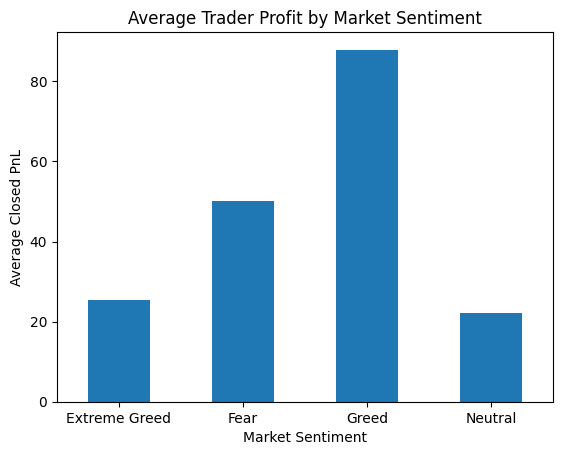

In [25]:
grouped.plot(kind='bar')

plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.title('Average Trader Profit by Market Sentiment')
plt.xticks(rotation=0)

plt.show()

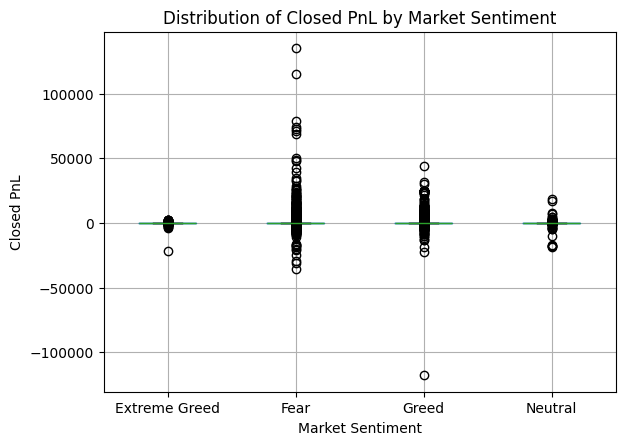

In [26]:
df.boxplot(column='Closed PnL', by='classification')

plt.title('Distribution of Closed PnL by Market Sentiment')
plt.suptitle('')  # removes automatic pandas title
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')

plt.show()

Percentage Profitable trades by sentiment

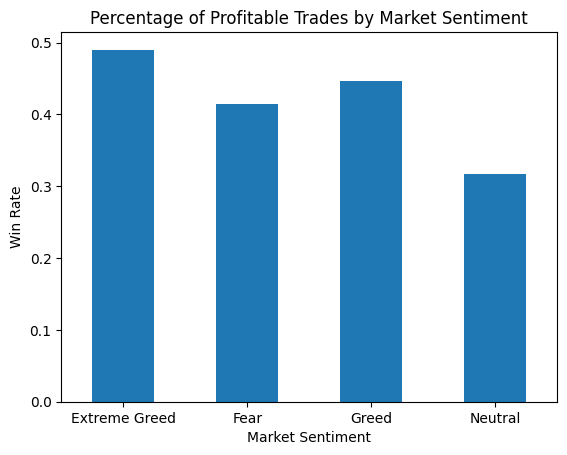

In [27]:
win_rate = df.groupby('classification')['Closed PnL'].apply(lambda x: (x > 0).mean())

win_rate.plot(kind='bar')

plt.title('Percentage of Profitable Trades by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate')
plt.xticks(rotation=0)

plt.show()

# Direction vs Sentiment 

In [28]:
grouped_d = df.groupby('Direction')['Closed PnL'].mean()
grouped_d

Direction
Auto-Deleveraging       7184.807003
Buy                        0.000000
Close Long                69.191429
Close Short              148.059254
Long > Short              36.362308
Open Long                  0.000000
Open Short                 0.000000
Sell                     161.285380
Settlement               -29.215368
Short > Long             187.568677
Spot Dust Conversion       0.000000
Name: Closed PnL, dtype: float64

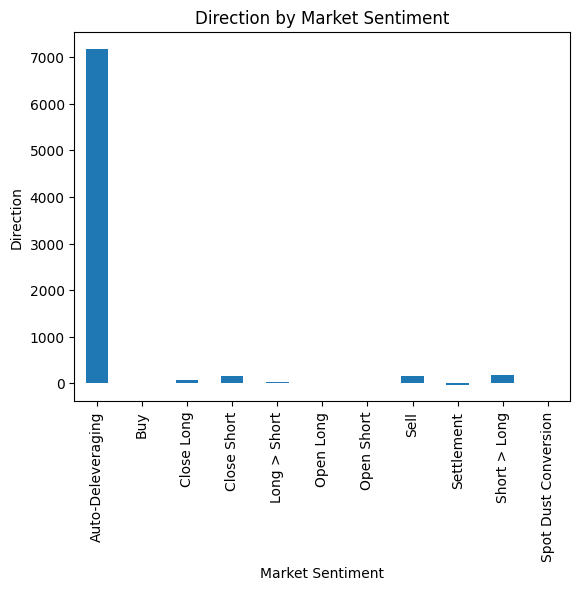

In [29]:
grouped_d.plot(kind='bar')

plt.xlabel('Market Sentiment')
plt.ylabel('Direction')
plt.title('Direction by Market Sentiment')

plt.show()

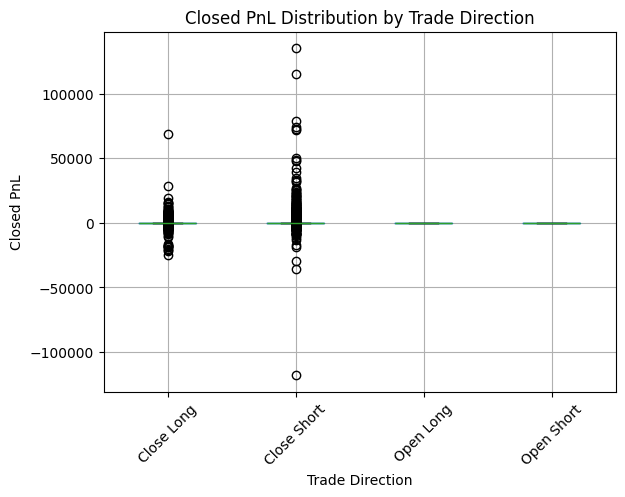

In [30]:
core_directions = [
    'Open Long', 'Close Long',
    'Open Short', 'Close Short'
]

df_core = df[df['Direction'].isin(core_directions)]

df_core.boxplot(column='Closed PnL', by='Direction')

plt.title('Closed PnL Distribution by Trade Direction')
plt.suptitle('')
plt.xlabel('Trade Direction')
plt.ylabel('Closed PnL')
plt.xticks(rotation=45)

plt.show()

# Risk Behavior

In [31]:
grouped_s = df.groupby('classification')['Size USD'].mean()
grouped_s

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

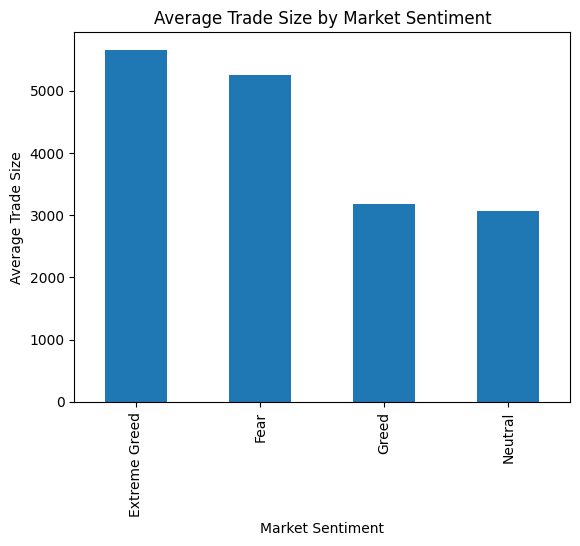

In [32]:
grouped_s.plot(kind='bar')

plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size')
plt.title('Average Trade Size by Market Sentiment')

plt.show()

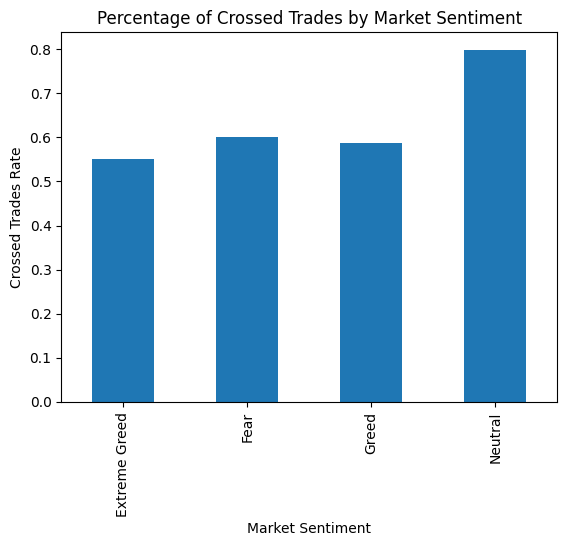

In [33]:
crossed_rate = df.groupby('classification')['Crossed'].apply(lambda x: (x == True).mean())

crossed_rate.plot(kind='bar')

plt.title('Percentage of Crossed Trades by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Crossed Trades Rate')

plt.show()

# PnL Efficiency 

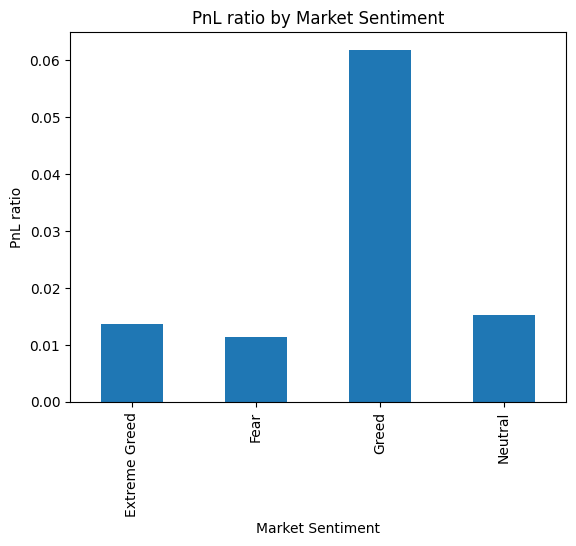

In [34]:
efficiency = df.groupby('classification')['pnl_ratio'].mean()

efficiency.plot(kind='bar')

plt.title('PnL ratio by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('PnL ratio')

plt.show()

In [35]:
efficiency

classification
Extreme Greed    0.013736
Fear             0.011358
Greed            0.061848
Neutral          0.015259
Name: pnl_ratio, dtype: float64

# Who survives different sentiments?

In [40]:
trader_sentiment_pnl = (
    df.groupby(['Account', 'classification'])['Closed PnL']
      .sum()
      .reset_index())

In [42]:
trader_sentiment_pnl['survivor'] = trader_sentiment_pnl['Closed PnL'] > 0
trader_sentiment_pnl

,Account,classification,Closed PnL,survivor
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1.927736e+06,True
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,-3.275059e+05,False
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Fear,1.709873e+04,True
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Greed,2.060745e+04,True
4,0x271b280974205ca63b716753467d5a371de622ab,Fear,2.997093e+04,True
...,...,...,...,...
69,0xbaaaf6571ab7d571043ff1e313a9609a10637864,Fear,9.401572e+05,True
70,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,Fear,3.254420e+05,True
71,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,Greed,1.167168e+04,True
72,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,Fear,1.269680e+05,True


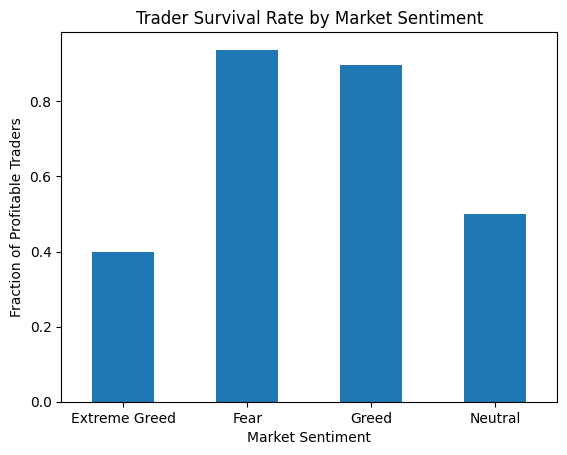

In [43]:
survival_rate = (
    trader_sentiment_pnl
    .groupby('classification')['survivor']
    .mean())
survival_rate.plot(kind='bar')

plt.title('Trader Survival Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Fraction of Profitable Traders')
plt.xticks(rotation=0)

plt.show()